# ShopEase E-Commerce Sales & Customer Analytics

**Company:** ShopEase  
**Project Type:** E-Commerce Data Analysis  
**Tools:** Python, Pandas, Matplotlib

## Project Overview

ShopEase is an e-commerce company that wants to understand its sales performance, customer behavior, product performance, and payment preferences.

This project analyzes ShopEase's sales data to identify business trends and opportunities.

## Business Question

**How is our business performing, what is driving sales, and where are we losing opportunities?**

## Objectives

- Analyze overall sales performance
- Identify high-performing products and categories
- Understand monthly sales trends
- Compare sales across cities
- Identify high-value customers
- Analyze payment method usage
- Evaluate sales across different discount levels
- Provide actionable business recommendations

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
from google.colab import files

uploaded = files.upload()

Saving shopease_sales_data.csv to shopease_sales_data (1).csv


In [30]:
df = pd.read_csv("shopease_sales_data.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Product,Quantity,Discount,City,Payment_Method,Category,Unit_Price,Sales
0,10001,2025-04-13,2016,Sneakers,4,0.05,Mumbai,UPI,Clothing,3200,12160.0
1,10002,2025-12-15,2129,Jeans,4,0.05,Visakhapatnam,UPI,Clothing,1800,6840.0
2,10003,2025-09-28,2575,Jeans,5,0.00,Mumbai,Cash on Delivery,Clothing,1800,9000.0
3,10004,2025-04-17,2109,Sneakers,2,0.10,Pune,UPI,Clothing,3200,5760.0
4,10005,2025-03-13,2533,Jeans,5,0.10,Mumbai,Cash on Delivery,Clothing,1800,8100.0


## Data Exploration

In [31]:
print(df.shape)

(3010, 11)


In [32]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Quantity',
       'Discount', 'City', 'Payment_Method', 'Category', 'Unit_Price',
       'Sales'],
      dtype='object')


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        3010 non-null   int64  
 1   Order_Date      3010 non-null   object 
 2   Customer_ID     3010 non-null   int64  
 3   Product         3010 non-null   object 
 4   Quantity        3010 non-null   int64  
 5   Discount        3010 non-null   float64
 6   City            3003 non-null   object 
 7   Payment_Method  3002 non-null   object 
 8   Category        3010 non-null   object 
 9   Unit_Price      3010 non-null   int64  
 10  Sales           3010 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 258.8+ KB
None


## Data Cleaning

In [34]:
print("Before cleaning:")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Fill missing values
df["City"] = df["City"].fillna("Unknown")
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")

# Convert date column
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Before cleaning:
Shape: (3010, 11)
Missing values: 15
Duplicate rows: 10

After cleaning:
Shape: (3000, 11)
Missing values: 0
Duplicate rows: 0


## KPI Summary


In [35]:
# KPI Summary

total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_quantity = df["Quantity"].sum()
aov = total_sales / total_orders

print("Total Sales: ₹", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value: ₹", round(aov, 2))

Total Sales: ₹ 88237535.0
Total Orders: 3000
Total Customers: 774
Total Quantity Sold: 9089
Average Order Value: ₹ 29412.51


## Product Analysis

In [36]:
product_analysis = df.groupby("Product").agg(
    Orders=("Order_ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum")
)

product_analysis["AOV"] = product_analysis["Sales"] / product_analysis["Orders"]

product_analysis = product_analysis.sort_values("Sales", ascending=False)

print(product_analysis)

               Orders  Quantity       Sales            AOV
Product                                                   
Laptop            236       713  36432000.0  154372.881356
Smartphone        314      1002  26163200.0   83322.292994
Smartwatch        280       854   5201300.0   18576.071429
Desk              141       407   4529400.0   32123.404255
Office Chair      179       507   4023050.0   22475.139665
Headphones        390      1187   2751875.0    7056.089744
Sneakers          228       670   1974880.0    8661.754386
Mixer Grinder     185       544   1914060.0   10346.270270
Coffee Maker      147       448   1858725.0   12644.387755
Jeans             304       927   1551960.0    5105.131579
T-Shirt           377      1175    979515.0    2598.183024
Backpack          219       655    857570.0    3915.844749


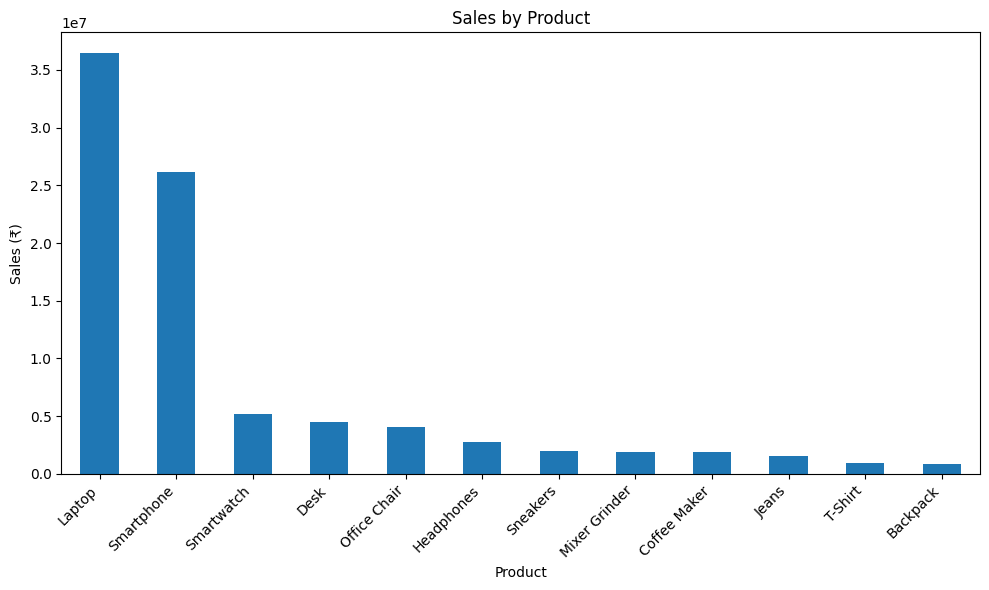

In [37]:
plt.figure(figsize=(10, 6))

product_analysis["Sales"].plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Category Analysis

In [38]:
category_analysis = df.groupby("Category").agg(
    Orders=("Order_ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum")
)

category_analysis["AOV"] = (
    category_analysis["Sales"] / category_analysis["Orders"]
)

category_analysis = category_analysis.sort_values(
    "Sales", ascending=False
)

print(category_analysis)

                Orders  Quantity       Sales           AOV
Category                                                  
Electronics       1220      3756  70548375.0  57826.536885
Furniture          320       914   8552450.0  26726.406250
Clothing           909      2772   4506355.0   4957.486249
Home & Kitchen     332       992   3772785.0  11363.810241
Accessories        219       655    857570.0   3915.844749


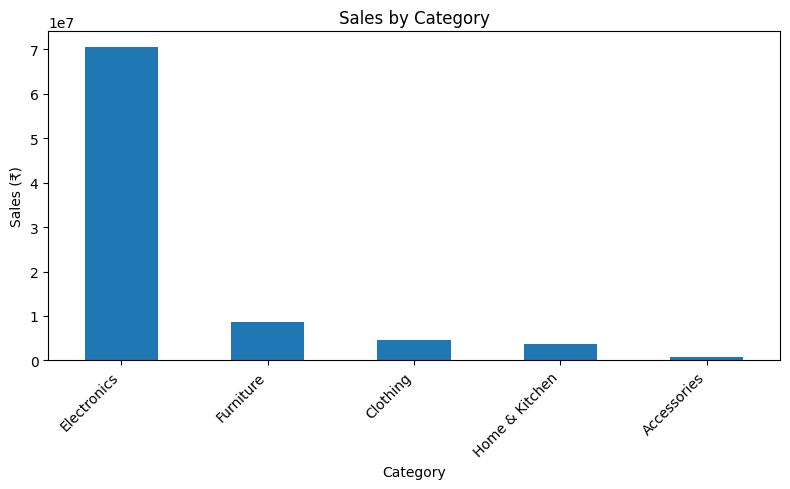

In [39]:
# Category Sales Analysis

plt.figure(figsize=(8, 5))
category_analysis["Sales"].plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Monthly Sales Analysis

In [40]:
# Monthly Sales Analysis

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales"].sum()

print(monthly_sales)

Order_Date
2025-01    7539265.0
2025-02    7963255.0
2025-03    6668700.0
2025-04    7097955.0
2025-05    7185205.0
2025-06    6146565.0
2025-07    6993475.0
2025-08    7917305.0
2025-09    7172590.0
2025-10    7341865.0
2025-11    7452345.0
2025-12    8759010.0
Freq: M, Name: Sales, dtype: float64


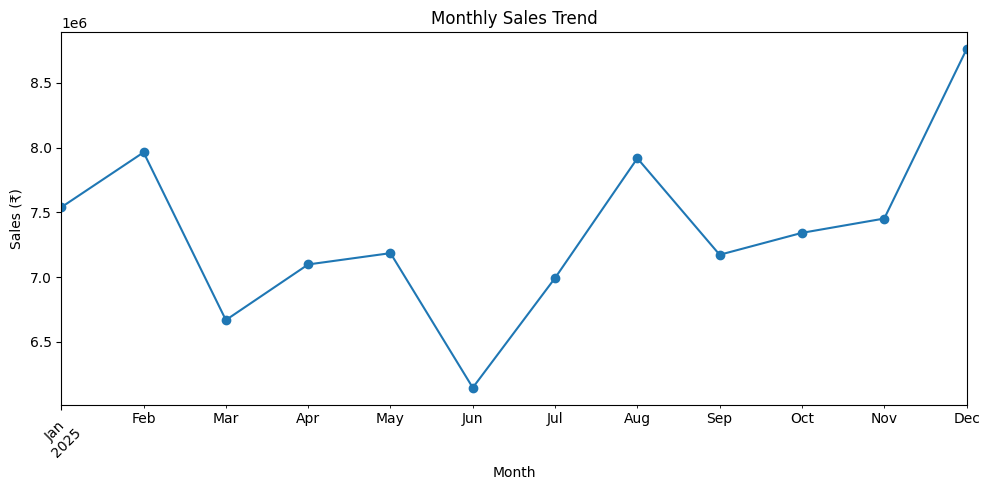

In [41]:
# Monthly Sales Trend

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## City Analysis

In [42]:
# City Sales Analysis

city_analysis = df.groupby("City").agg(
    Orders=("Order_ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum")
)

city_analysis["AOV"] = (
    city_analysis["Sales"] / city_analysis["Orders"]
)

city_analysis = city_analysis.sort_values(
    "Sales", ascending=False
)

print(city_analysis)

               Orders  Quantity       Sales           AOV
City                                                     
Delhi             316       958  10272025.0  32506.408228
Kolkata           290       895   9979360.0  34411.586207
Hyderabad         292       899   9046375.0  30980.736301
Vijayawada        312       949   8931665.0  28627.131410
Pune              292       844   8761515.0  30005.188356
Ahmedabad         304       927   8722010.0  28690.822368
Visakhapatnam     313       938   8594915.0  27459.792332
Chennai           284       884   8397135.0  29567.376761
Mumbai            300       905   8028050.0  26760.166667
Bengaluru         290       868   7252555.0  25008.810345
Unknown             7        22    251930.0  35990.000000


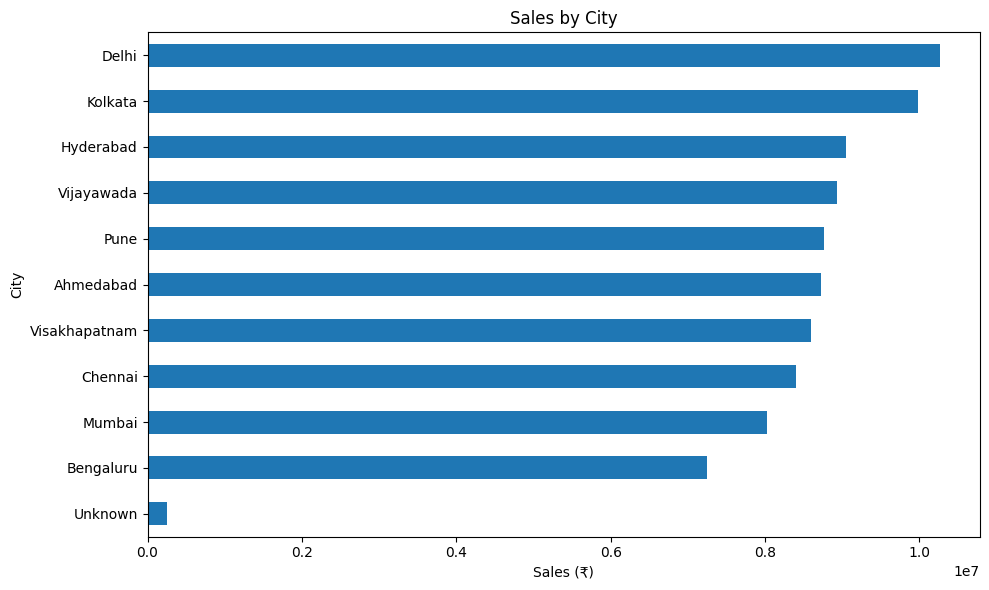

In [43]:
# City Sales Chart

plt.figure(figsize=(10, 6))
city_analysis["Sales"].sort_values().plot(kind="barh")

plt.title("Sales by City")
plt.xlabel("Sales (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## Customer Analysis

In [44]:
# Customer Sales Analysis

customer_analysis = df.groupby("Customer_ID").agg(
    Orders=("Order_ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum")
)

customer_analysis["AOV"] = (
    customer_analysis["Sales"] / customer_analysis["Orders"]
)

customer_analysis = customer_analysis.sort_values(
    "Sales", ascending=False
)

print(customer_analysis.head(10))

             Orders  Quantity     Sales            AOV
Customer_ID                                           
2338              6        24  674150.0  112358.333333
2420              6        23  619680.0  103280.000000
2025              7        26  614400.0   87771.428571
2450              8        26  593160.0   74145.000000
2289              4        13  588630.0  147157.500000
2471             11        33  506220.0   46020.000000
2612              4        16  499450.0  124862.500000
2013              8        28  496750.0   62093.750000
2579              5        16  452680.0   90536.000000
2207              8        27  447020.0   55877.500000


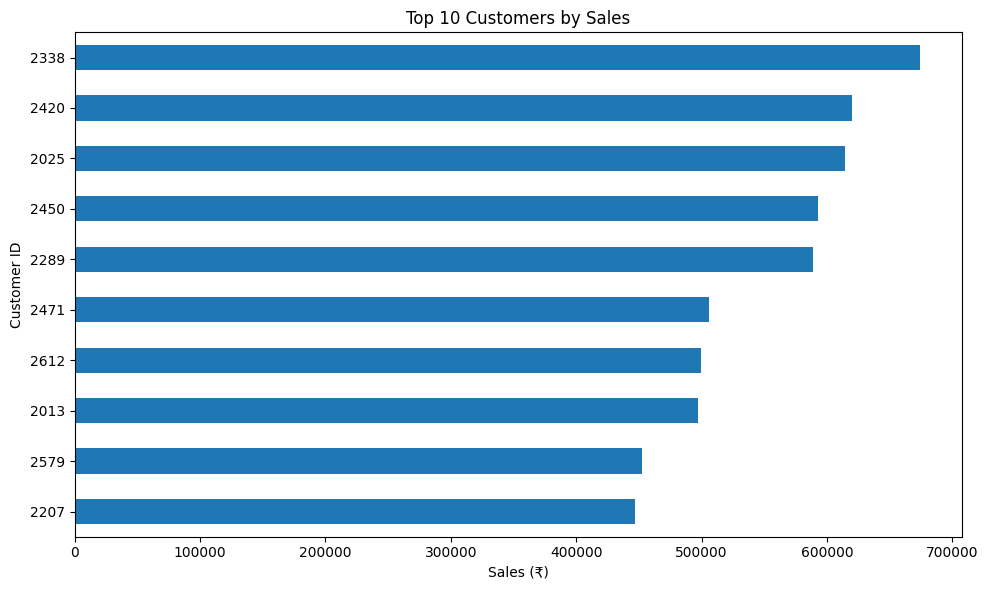

In [45]:
# Top 10 Customers by Sales

top_customers = customer_analysis.head(10)

plt.figure(figsize=(10, 6))
top_customers["Sales"].sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

## Payment Method Analysis

In [46]:
# Payment Method Analysis

payment_analysis = df.groupby("Payment_Method").agg(
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum")
)

payment_analysis["AOV"] = (
    payment_analysis["Sales"] / payment_analysis["Orders"]
)

payment_analysis = payment_analysis.sort_values(
    "Sales", ascending=False
)

print(payment_analysis)

                  Orders       Sales           AOV
Payment_Method                                    
UPI                 1155  32119565.0  27809.147186
Credit Card          685  21168185.0  30902.459854
Debit Card           479  14297670.0  29848.997912
Cash on Delivery     383  11779370.0  30755.535248
Net Banking          290   8638215.0  29786.948276
Unknown                8    234530.0  29316.250000


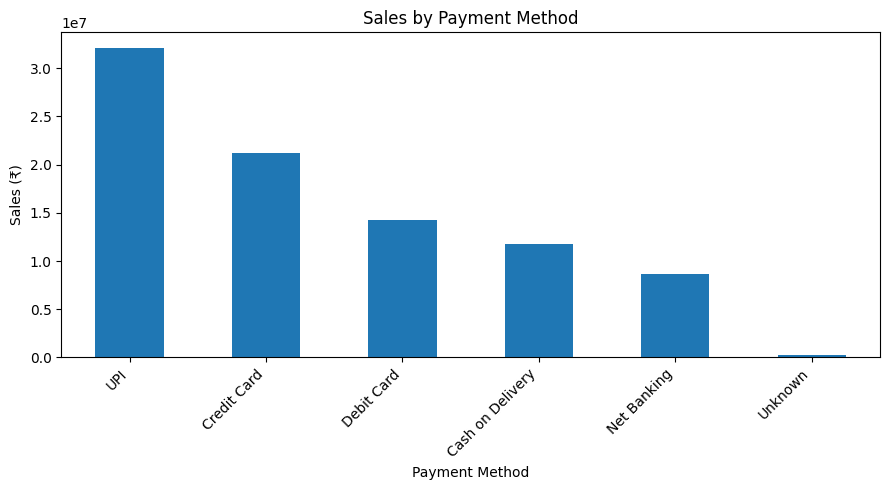

In [47]:
# Payment Method Sales Chart

plt.figure(figsize=(9, 5))
payment_analysis["Sales"].plot(kind="bar")

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Discount Analysis

In [48]:
# Discount Analysis

discount_analysis = df.groupby("Discount").agg(
    Orders=("Order_ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum")
)

discount_analysis["AOV"] = (
    discount_analysis["Sales"] / discount_analysis["Orders"]
)

print(discount_analysis)

          Orders  Quantity       Sales           AOV
Discount                                            
0.00         887      2678  28562100.0  32200.789177
0.05         759      2285  23566840.0  31049.855072
0.10         753      2290  19733490.0  26206.494024
0.15         445      1339  12389345.0  27841.224719
0.20         156       497   3985760.0  25549.743590


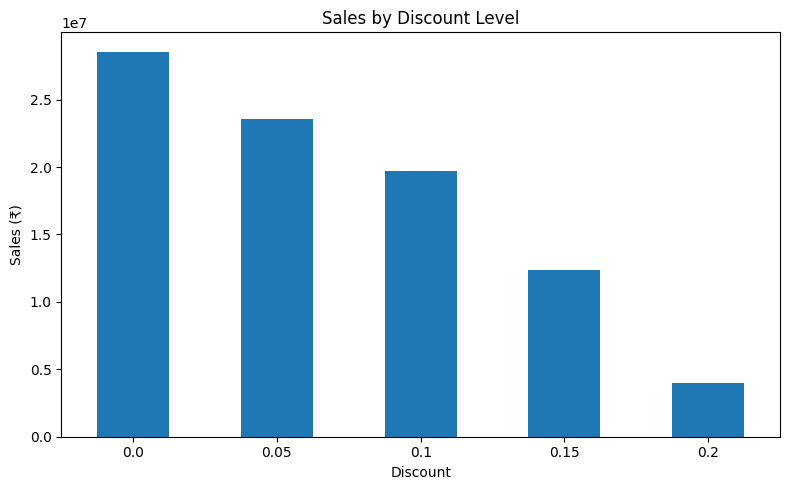

In [49]:
# Discount vs Sales

plt.figure(figsize=(8, 5))
discount_analysis["Sales"].plot(kind="bar")

plt.title("Sales by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Business Insights

### 1. Product Performance
- Laptop generated the highest sales at ₹3.64 crore.
- Smartphone generated the second-highest sales at ₹2.62 crore.
- Headphones and T-Shirts had high quantities sold but much lower sales compared with Laptop and Smartphone.

### 2. Category Performance
- Electronics was the strongest category, generating ₹7.05 crore in sales.
- Clothing had high order volume but a much lower AOV than Electronics.
- Accessories was the weakest category by sales.

### 3. Monthly Sales Performance
- December recorded the highest monthly sales at ₹87.59 lakh.
- June recorded the lowest monthly sales at ₹61.47 lakh.
- Sales fluctuated throughout the year, suggesting that monthly patterns should be considered for inventory and promotional planning.

### 4. City Performance
- Delhi generated the highest sales at ₹1.03 crore.
- Kolkata was the second-highest city at ₹99.79 lakh.
- Bengaluru had the lowest sales among the major cities at ₹72.53 lakh.

### 5. Customer Performance
- Customer 2338 generated the highest sales among individual customers at ₹6.74 lakh.
- Some customers generated high sales with relatively few orders, indicating the importance of high-value purchases.

### 6. Payment Method Performance
- UPI was the most-used payment method and generated the highest total sales.
- Credit Card had the highest AOV at approximately ₹30,902.

### 7. Discount Performance
- Orders and sales were highest at the 0% discount level.
- Higher discount levels were associated with lower order volume and sales in this dataset.
- This relationship should not be interpreted as causation without further analysis.


## Business Recommendations

### 1. Focus on High-Performing Products
- Prioritize Laptop and Smartphone inventory and marketing.
- Monitor demand closely to avoid stockouts of top-selling products.

### 2. Improve Weak Product Performance
- Investigate why products such as Backpack and T-Shirt generate relatively low sales.
- Consider product positioning, pricing, and targeted promotions.

### 3. Strengthen High-Performing Categories
- Continue investing in the Electronics category because it is the strongest sales contributor.
- Review Accessories and Clothing to identify opportunities to improve revenue and AOV.

### 4. Use Monthly Sales Patterns
- Prepare inventory and marketing strategies around stronger sales periods.
- Investigate the reasons behind the December sales peak and June sales decline.

### 5. Target High-Value Customers
- Create loyalty programs and personalized offers for high-value customers.
- Encourage repeat purchases from customers with strong spending potential.

### 6. Optimize Payment Experience
- Continue supporting UPI because it is the most-used payment method.
- Maintain multiple payment options to serve different customer preferences.

### 7. Review Discount Strategy
- Evaluate discounts based on incremental sales and profitability rather than assuming larger discounts create more demand.
- Test targeted discounts instead of applying high discounts broadly..